# 1. See the density of MA layer

In [1]:
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import numpy as np
import matplotlib.pyplot as plt
import napari
import mrcfile
import jax
import jax.numpy as jnp
import napari
from sklearn.cluster import KMeans
from skimage.measure import marching_cubes
from scipy.ndimage import binary_dilation

from pinn.model import (
    PINN,
    WEIGHT_IN, 
    EPSILON,
    LEARNING_RATE
) 
from pinn.checkpoint_io import load_checkpoint_at_step
from pinn.cryoet_io import open_mrc, save_mrc
from pinn.plot import (
    visualize_checkpoint_level_set,
    visualize_checkpoint_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.grid import phi_on_cryo_grid_xyz
from pinn.plot import _to_zyx, visualize_zyx_midslice, visualize_zyx_midslice_vs_overlay
from pinn.train import create_train_state

#### Average the good results

In [2]:
import re

# Original shape
# ------------------------------------------------------------
shape = "62_normalized"
data_dir = "VLP_Cropped"
result_shape = "62_normalized_preprocessed_2"

data_path1 = f"../data/{data_dir}/{shape}.mrc"
norm_data = open_mrc(data_path1)

checkpoint_dirs = [
    "../outputs/logs/62_normalized_preprocessed_2/lambda_8858667.904100832_300_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_14384498.882876629_600_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_1200_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_61584821.10660254_1400_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_2069138.0811147902_100_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_14384498.882876629_300_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_23357214.690901212_1000_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_14384498.882876629_1500_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_23357214.690901212_1500_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_1600_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_1500_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_1900_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_1800_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_1700_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_23357214.690901212_1400_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_1400_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_61584821.10660254_1300_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_23357214.690901212_1200_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_23357214.690901212_700_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint",
    "../outputs/logs/62_normalized_preprocessed_2/lambda_37926901.90732246_600_weightIn_0.5_epsilon_0.05_Learning_0.001/checkpoint"
]

step = 10000
weight_in = 0.5
epsilon = EPSILON
lr = LEARNING_RATE

# Running average over phi_zyx across checkpoints
# ------------------------------------------------------------
phi_zyx_avg = np.zeros(norm_data.shape, dtype=np.float32)
count = 0

pattern = re.compile(
    r"lambda_([0-9\.eE+-]+)_([0-9\.eE+-]+)_"
)

for checkpoint_dir in checkpoint_dirs:

    # Skip missing checkpoints instead of crashing

    if not os.path.isdir(checkpoint_dir):
        print(f"[skip] Missing checkpoint dir: {checkpoint_dir}")
        continue

    # Extract folder name containing lambda info
    run_dir = os.path.basename(os.path.dirname(checkpoint_dir))

    m = pattern.search(run_dir)
    if m is None:
        print(f"[skip] Failed to parse lambda from: {run_dir}")
        continue

    lambda_1 = float(m.group(1))
    lambda_2 = int(float(m.group(2)))

    # Load checkpoint at a specific step
    checkpoint_data = load_checkpoint_at_step(step, checkpoint_dir, lambda_1, lambda_2)
    if checkpoint_data is None:
        print(f"[skip] Failed to load checkpoint at step={step}: {checkpoint_dir}")
        continue

    state = checkpoint_data["state"]
    params = state["params"]

    # Build phi function
    model = PINN()
    phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))

    # Evaluate phi on cryo grid (XYZ -> convert to ZYX)
    phi_xyz, _, _ = phi_on_cryo_grid_xyz(phi_fn, norm_data.shape, lo=-1.0, hi=1.0)
    phi_zyx_curr = _to_zyx(np.array(phi_xyz)).astype(np.float32, copy=False)

    # Safety check: shape consistency
    if phi_zyx_curr.shape != phi_zyx_avg.shape:
        print(f"[skip] Shape mismatch: got {phi_zyx_curr.shape}, expected {phi_zyx_avg.shape}")
        continue

    # Online (streaming) average update:
    # avg_{n+1} = avg_n + (x_{n+1} - avg_n) / (n+1)
    count += 1
    phi_zyx_avg += (phi_zyx_curr - phi_zyx_avg) / count

    print(f"[ok] averaged ({lambda_1}, {lambda_2})  -> count={count}")

print(f"Done. count={count}, phi_zyx_avg shape={phi_zyx_avg.shape}, dtype={phi_zyx_avg.dtype}")


Data shape: (172, 332, 373)
Voxel size (angstroms): (0.0, 0.0, 0.0)
[ok] averaged (8858667.904100832, 300)  -> count=1
[ok] averaged (14384498.882876629, 600)  -> count=2
[ok] averaged (37926901.90732246, 1200)  -> count=3
[ok] averaged (61584821.10660254, 1400)  -> count=4
[ok] averaged (2069138.0811147902, 100)  -> count=5
[ok] averaged (14384498.882876629, 300)  -> count=6
[ok] averaged (23357214.690901212, 1000)  -> count=7
[ok] averaged (14384498.882876629, 1500)  -> count=8
[ok] averaged (23357214.690901212, 1500)  -> count=9
[ok] averaged (37926901.90732246, 1600)  -> count=10
[ok] averaged (37926901.90732246, 1500)  -> count=11
[ok] averaged (37926901.90732246, 1900)  -> count=12
[ok] averaged (37926901.90732246, 1800)  -> count=13
[ok] averaged (37926901.90732246, 1700)  -> count=14
[ok] averaged (23357214.690901212, 1400)  -> count=15
[ok] averaged (37926901.90732246, 1400)  -> count=16
[ok] averaged (61584821.10660254, 1300)  -> count=17
[ok] averaged (23357214.690901212, 12

In [6]:
avg_path = f"../data/{data_dir}/{result_shape}_selected_avg.mrc"
save_mrc(avg_path, phi_zyx_avg)

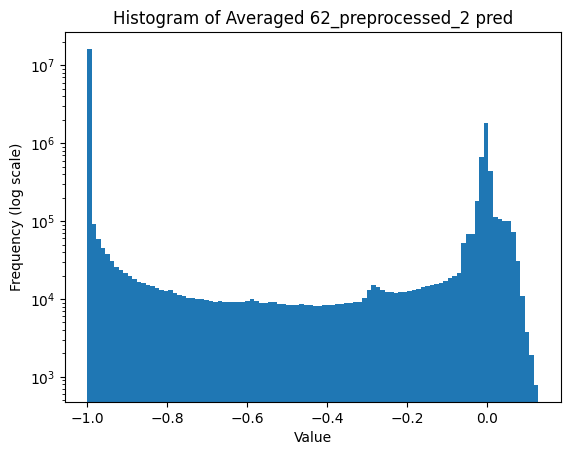

In [28]:
import matplotlib.pyplot as plt
plt.hist(phi_zyx_avg.ravel(), bins=100)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Averaged 62_preprocessed_2 pred')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

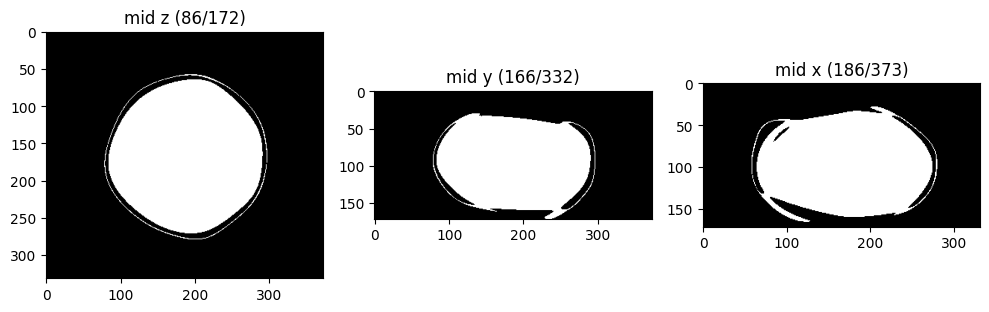

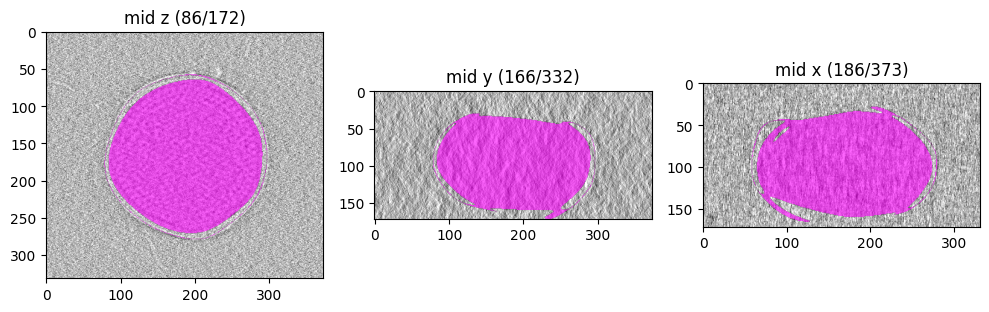

In [27]:
phi_zyx_avg_mask = np.where(abs(phi_zyx_avg) < 0.03, 1, 0)

visualize_zyx_midslice(phi_zyx_avg_mask)
visualize_zyx_midslice_vs_overlay(norm_data, phi_zyx_avg_mask, alpha=0.6)

#### Non-linear stretch

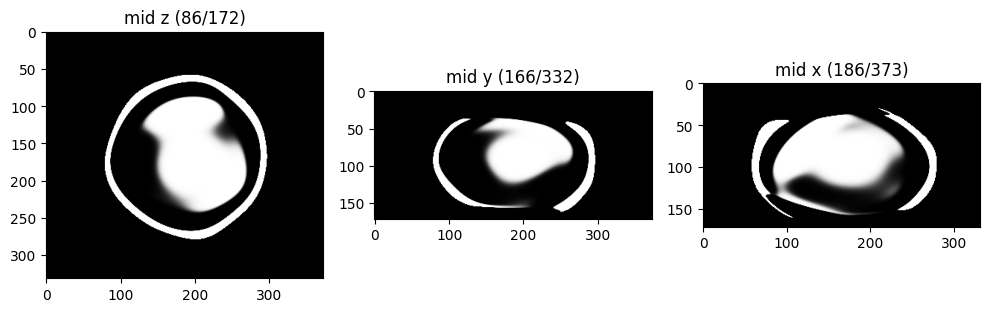

In [32]:
def stretch_tanh(phi, alpha=0.05):
    return np.tanh(phi / alpha)

phi_vis = stretch_tanh(phi_zyx_avg, alpha=0.001)
visualize_zyx_midslice(phi_vis)

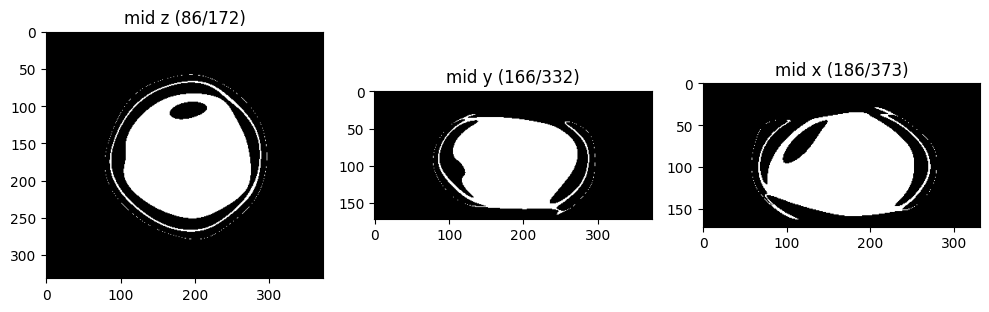

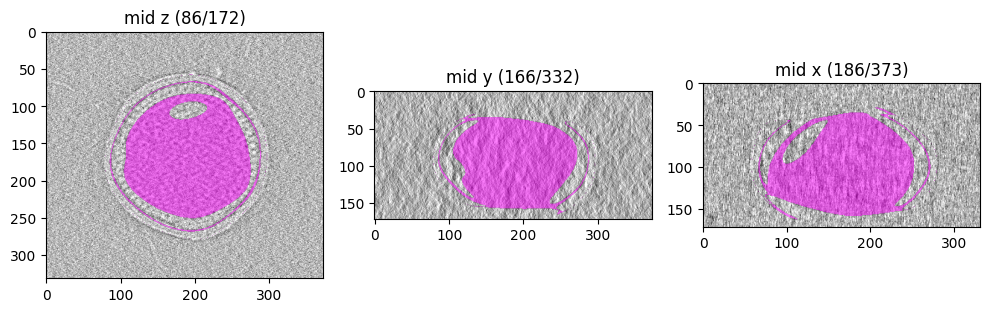

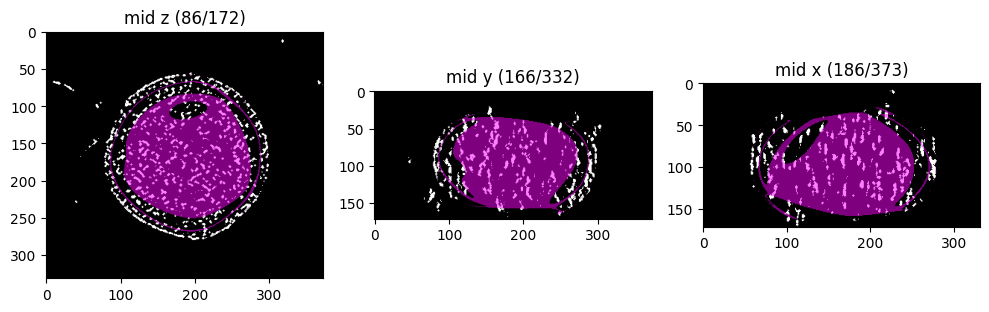

In [60]:
def stretch_exp_band(phi, t=0.1, alpha=0.02):
    phi = np.asarray(phi)
    out = np.zeros_like(phi, dtype=np.float32)

    mask = np.abs(phi) <= t
    out[mask] = np.exp(-(phi[mask] / alpha) ** 2)
    return out

phi_stretch = stretch_exp_band(phi_zyx_avg, t=0.008, alpha=2)
visualize_zyx_midslice(phi_stretch)
visualize_zyx_midslice_vs_overlay(norm_data, phi_stretch)
visualize_zyx_midslice_vs_overlay(binary_data, phi_stretch)

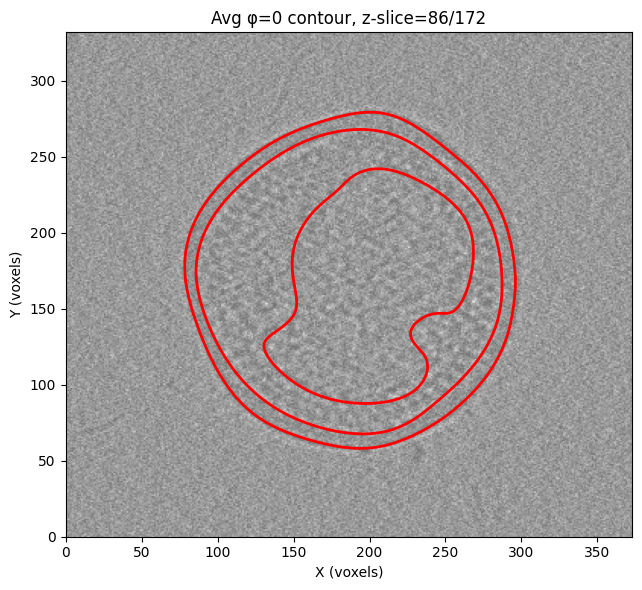

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# z-mid slice (voxel coords)
# -----------------------------
Z, Y, X = phi_zyx_avg.shape
slice_index = Z // 2

# voxel index axes
x_axis = np.arange(X)   # 0 ... X-1
y_axis = np.arange(Y)   # 0 ... Y-1

cryo_slice = np.array(norm_data[slice_index])      # (Y, X)
slice_phi  = np.array(phi_zyx_avg[slice_index])    # (Y, X)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 6))

custom_gray = LinearSegmentedColormap.from_list(
    "custom_gray", ["#f0f0f0", "#777777"]
)

ax.imshow(
    cryo_slice,
    cmap=custom_gray,
    origin="lower",
    extent=[0, X, 0, Y],   # 👈 voxel extent
    alpha=1.0,
)

# φ = 0 contour in voxel space
X2, Y2 = np.meshgrid(x_axis, y_axis, indexing="xy")
ax.contour(X2, Y2, slice_phi, levels=[0], colors="red", linewidths=2.0)

# Labels / title
ax.set_xlabel("X (voxels)")
ax.set_ylabel("Y (voxels)")
ax.set_title(f"Avg φ=0 contour, z-slice={slice_index}/{Z}")

plt.tight_layout()
plt.show()


In [ ]:
shape = "62_normalized"
result_shape = "62_normalized_bandpass_dilation_erosion"
data_dir = "VLP_Cropped"
data_path1 = f"../data/{data_dir}/{shape}.mrc"
data_path2 = f"../data/{data_dir}/{result_shape}.mrc"
lambda_1 = 4000000
lambda_2 = 500

norm_data = open_mrc(data_path1)
binary_data = open_mrc(data_path2)

checkpoint_dir = os.path.abspath(
    f"../outputs/logs/{result_shape}/lambda_{lambda_1}_{lambda_2}_weightIn_{0.5}_epsilon_{EPSILON}_Learning_{LEARNING_RATE}/checkpoint"
)
checkpoint_data = load_checkpoint_at_step(10000, checkpoint_dir, lambda_1, lambda_2)
state = checkpoint_data["state"]; params = state["params"]
model = PINN()
phi_fn = lambda x: model.apply(params, x.reshape(-1, 3))
phi_xyz, _, (x_axis, y_axis, z_axis) = phi_on_cryo_grid_xyz(phi_fn, norm_data.shape, lo=-1.0, hi=1.0)
phi_zyx = _to_zyx(np.array(phi_xyz))  

In [ ]:
def napari_gradient(data, ori):
    # binary mask: shape (Z, Y, X)
    mask = data.astype(np.float32)

    # 중심 좌표 계산
    z0, y0, x0 = np.array(mask.shape) / 2

    # 각 voxel의 거리 계산
    zz, yy, xx = np.meshgrid(
        np.arange(mask.shape[0]),
        np.arange(mask.shape[1]),
        np.arange(mask.shape[2]),
        indexing="ij"
    )

    distance = np.sqrt((zz - z0)**2 + (yy - y0)**2 + (xx - x0)**2)

    # 거리 정규화: 0.2 ~ 1.0 사이로 스케일링
    distance_norm = 0.2 + 0.8 * (distance / distance.max())

    # gradient mask 생성
    gradient_mask = mask * distance_norm ** 2

    # napari 시각화
    viewer = napari.Viewer()
    viewer.add_image(gradient_mask.astype(np.float32), name="Center-Distance Gradient", colormap="twilight", blending="additive", opacity=0.5)
    if ori is not None:
        viewer.add_image(ori.astype(np.float32), name="Original Data", colormap="gray", blending="additive", opacity=0.5)
    napari.run()

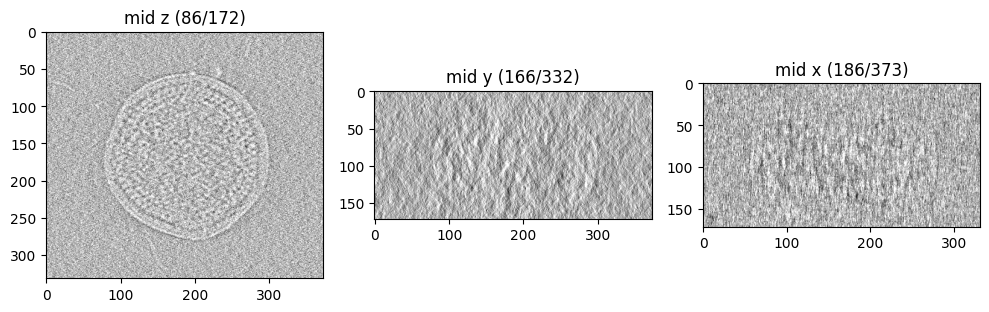

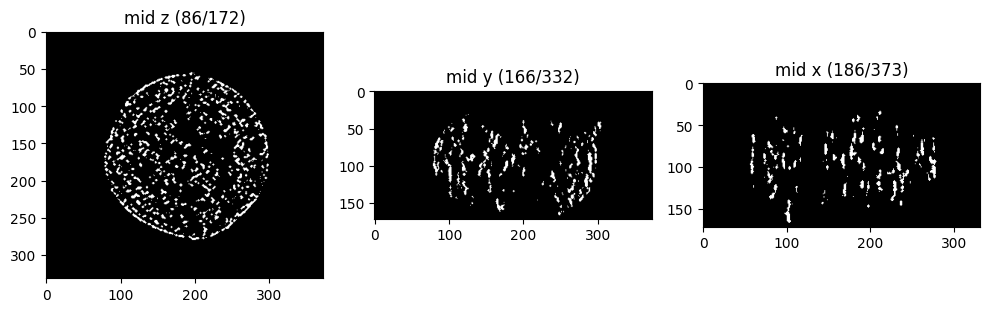

In [3]:
visualize_zyx_midslice(norm_data)
visualize_zyx_midslice(binary_data)

In [63]:
def split_outer_middle_inner(phi_zyx, k=3, thickness_dilate=1):
    """
    φ=0 iso-surface를 marching_cubes로 얻고
    (r, a) 기반 k-means(k=3)로 outer/middle/inner 분리.

    return:
        inner_mask, middle_mask, outer_mask
    """
    Z, Y, X = phi_zyx.shape

    # 1) marching cubes: surface point cloud + normals
    verts, faces, normals, values = marching_cubes(phi_zyx, level=0.0)

    # 2) 중심점 추정
    cz, cy, cx = np.array(phi_zyx.shape) / 2.0
    center = np.array([cz, cy, cx])

    # 3) 반지름 r, 방향성 a 계산
    v = verts - center
    r = np.linalg.norm(v, axis=1)
    u = v / (r[:, None] + 1e-8)
    a = np.sum(u * normals, axis=1)   # outward=+1, inward=-1

    # 4) feature 구성 (r 표준화)
    r_std = (r - r.mean()) / (r.std() + 1e-8)
    feats = np.stack([r_std, a], axis=1)

    # 5) k-means(k=3)
    km = KMeans(n_clusters=k, n_init="auto", random_state=0)
    labels = km.fit_predict(feats)

    # 6) 평균 반지름으로 inner / middle / outer 결정
    mean_r = []
    for c in range(k):
        mean_r.append((c, r[labels == c].mean()))
    mean_r.sort(key=lambda t: t[1])   # 작은 r → inner

    inner_idx  = mean_r[0][0]
    middle_idx = mean_r[1][0]
    outer_idx  = mean_r[2][0]

    # 7) 각 cluster를 voxel로 rasterize
    def rasterize(cluster_idx):
        mask = np.zeros_like(phi_zyx, dtype=np.uint8)
        v = verts[labels == cluster_idx]
        zi = np.clip(np.round(v[:,0]).astype(int), 0, Z-1)
        yi = np.clip(np.round(v[:,1]).astype(int), 0, Y-1)
        xi = np.clip(np.round(v[:,2]).astype(int), 0, X-1)
        mask[zi, yi, xi] = 1
        if thickness_dilate > 0:
            mask = binary_dilation(mask, iterations=thickness_dilate).astype(np.uint8)
        return mask

    inner_mask  = rasterize(inner_idx)
    middle_mask = rasterize(middle_idx)
    outer_mask  = rasterize(outer_idx)

    return inner_mask, middle_mask, outer_mask


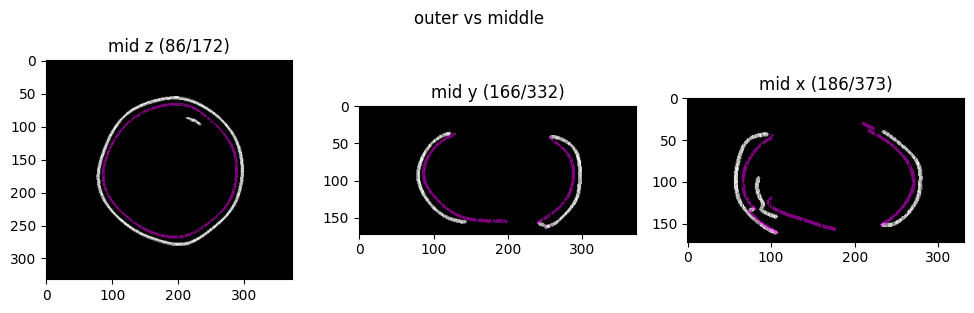

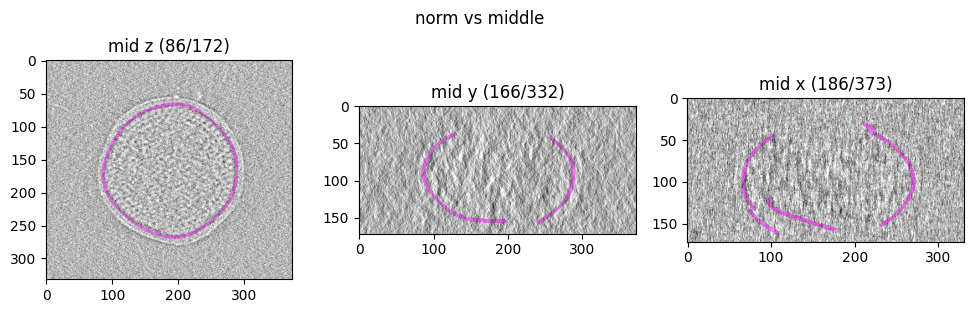

In [69]:
from skimage.measure import label, regionprops
inner_mask, middle_mask, outer_mask = split_outer_middle_inner(phi_zyx_avg, k=3, thickness_dilate=2)

lab = label(outer_mask, connectivity=3)
if lab.max() > 1:
    props = regionprops(lab)
    largest_region = max(props, key=lambda x: x.area)
    outer_mask = (lab == largest_region.label)

inner_layer  = norm_data * inner_mask
middle_layer = norm_data * middle_mask
outer_layer  = norm_data * outer_mask

visualize_zyx_midslice_vs_overlay(outer_layer, middle_layer, title="outer vs middle")
visualize_zyx_midslice_vs_overlay(norm_data, middle_layer, title="norm vs middle")

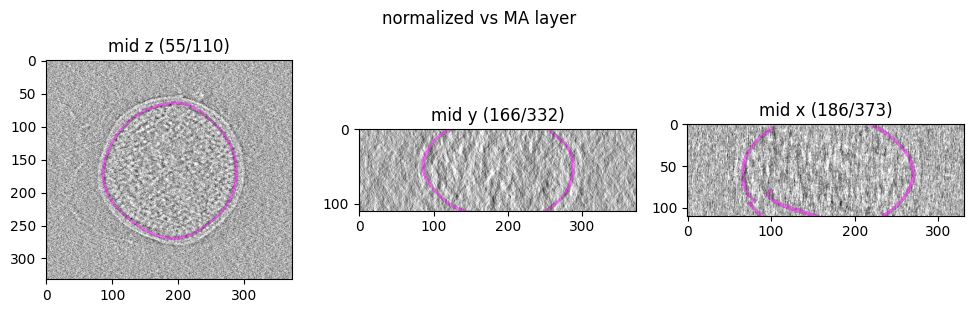

In [71]:
middle_layer_cropped = middle_layer[40:150,:,:]
outer_layer_cropped = outer_layer[40:150,:,:]
norm_data_cropped = norm_data[40:150,:,:]

middle_mask_cropped = middle_mask[40:150,:,:]
outer_mask_cropped = outer_mask[40:150,:,:]

visualize_zyx_midslice_vs_overlay(norm_data_cropped, middle_layer_cropped, title="normalized vs MA layer")

In [73]:
viewer = napari.Viewer()
viewer.add_image(norm_data_cropped.astype(np.float32), name="original_data", colormap="gray", blending="additive", opacity=0.5)
viewer.add_image(outer_layer_cropped.astype(np.float32), name="outer_layer_cropped", colormap="blue", blending="additive", opacity=0.5)
viewer.add_image(middle_layer_cropped.astype(np.float32), name="middle_layer_cropped", colormap="cyan", blending="additive", opacity=0.5)
napari.run()

# Archive

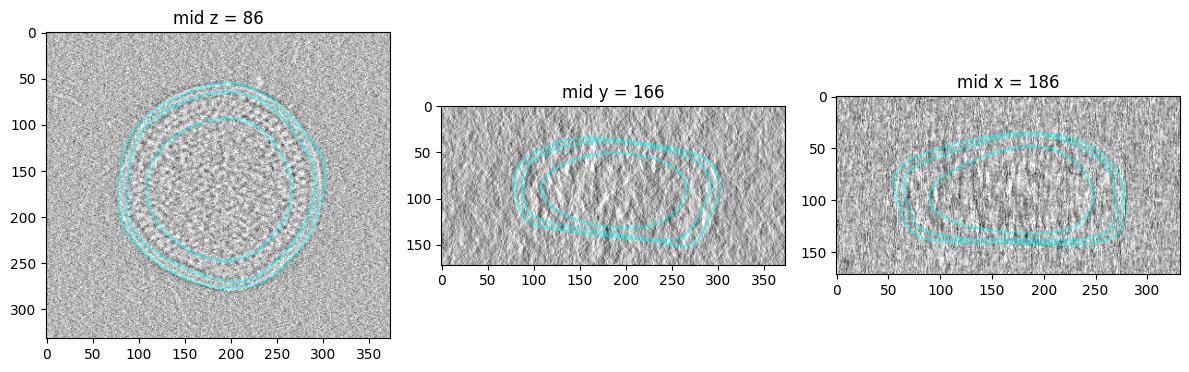

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 슬라이스 인덱스
slice_z_idx = z // 2
slice_y_idx = y // 2
slice_x_idx = x // 2

# --------- slice Z (y-x plane) ---------
slice_z = phi_zyx[slice_z_idx, :, :]   # shape: (y, x)

# 픽셀 좌표 meshgrid (no scaling)
Xz, Yz = np.meshgrid(np.arange(x), np.arange(y))

axes[0].imshow(data[slice_z_idx, :, :], cmap="gray", alpha=1.0)
axes[0].contour(Xz, Yz, slice_z, levels=[0.0],
               colors='cyan', linewidths=2, alpha=0.4)
axes[0].set_title(f"mid z = {slice_z_idx}")

# --------- slice Y (z-x plane) ---------
slice_y = phi_zyx[:, slice_y_idx, :]   # shape: (z, x)

Xy, Zy = np.meshgrid(np.arange(x), np.arange(z))

axes[1].imshow(data[:, slice_y_idx, :], cmap="gray", alpha=1.0)
axes[1].contour(Xy, Zy, slice_y, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[1].set_title(f"mid y = {slice_y_idx}")

# --------- slice X (z-y plane) ---------
slice_x = phi_zyx[:, :, slice_x_idx]   # shape: (z, y)

Yx, Zx = np.meshgrid(np.arange(y), np.arange(z))

axes[2].imshow(data[:, :, slice_x_idx], cmap="gray", alpha=1.0)
axes[2].contour(Yx, Zx, slice_x, levels=[0.0], colors='cyan', linewidths=2, alpha=0.4)
axes[2].set_title(f"mid x = {slice_x_idx}")

plt.tight_layout()
plt.show()

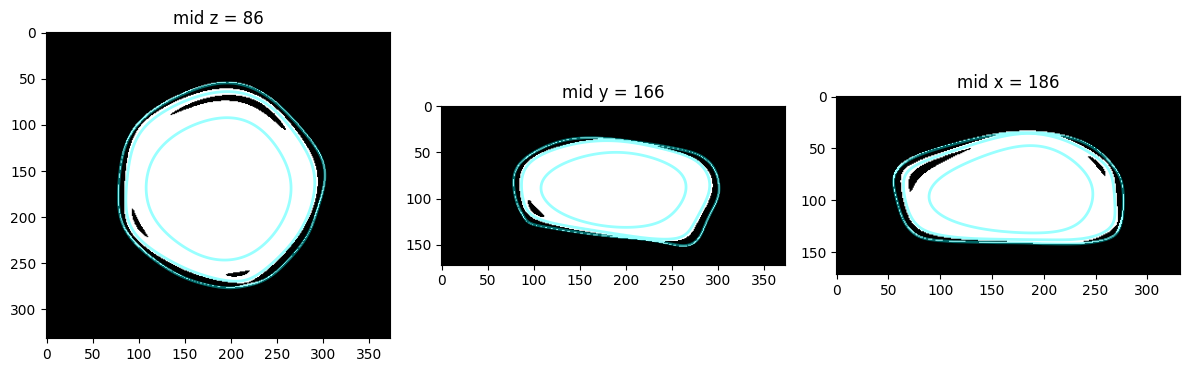

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 슬라이스 인덱스
slice_z_idx = z // 2 
slice_y_idx = y // 2 
slice_x_idx = x // 2 

# --------- slice Z (y-x plane) ---------
slice_z = phi_zyx[slice_z_idx, :, :]   # shape: (y, x)

# 픽셀 좌표 meshgrid (no scaling)
Xz, Yz = np.meshgrid(np.arange(x), np.arange(y))

axes[0].imshow(pred_mask[slice_z_idx, :, :], cmap="gray", alpha=1.0)
axes[0].contour(Xz, Yz, slice_z, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[0].set_title(f"mid z = {slice_z_idx}")

# --------- slice Y (z-x plane) ---------
slice_y = phi_zyx[:, slice_y_idx, :]   # shape: (z, x)

Xy, Zy = np.meshgrid(np.arange(x), np.arange(z))

axes[1].imshow(pred_mask[:, slice_y_idx, :], cmap="gray", alpha=1.0)
axes[1].contour(Xy, Zy, slice_y, levels=[0.0],
                colors='cyan', linewidths=2, alpha=0.4)
axes[1].set_title(f"mid y = {slice_y_idx}")

# --------- slice X (z-y plane) ---------
slice_x = phi_zyx[:, :, slice_x_idx]   # shape: (z, y)

Yx, Zx = np.meshgrid(np.arange(y), np.arange(z))

axes[2].imshow(pred_mask[:, :, slice_x_idx], cmap="gray", alpha=1.0)
axes[2].contour(Yx, Zx, slice_x, levels=[0.0], colors='cyan', linewidths=2, alpha=0.4)
axes[2].set_title(f"mid x = {slice_x_idx}")

plt.tight_layout()
plt.show()

# 2. Calculate the distance between MA vs Envelope layer

In [74]:
import numpy as np
from scipy.ndimage import distance_transform_edt

def outer_middle_distance_stats(outer_mask,
                                middle_mask,
                                voxel_size=(1.0, 1.0, 1.0)):
    """
    outer_mask, middle_mask : 3D binary (0/1) arrays, shape (Z, Y, X)
        - outer_mask : 바깥 leaflet surface/band
        - middle_mask: 가운데 leaflet surface/band
    voxel_size : (dz, dy, dx) 물리적 voxel 크기 (예: nm 단위)

    return:
        distances_outer_to_middle : 1D array, 각 outer voxel에서 middle까지 최근접 거리
        stats : dict(mean, median, std, min, max, n)
    """

    outer = outer_mask.astype(bool)
    middle = middle_mask.astype(bool)

    if not np.any(outer):
        raise ValueError("outer_mask has no foreground voxels.")
    if not np.any(middle):
        raise ValueError("middle_mask has no foreground voxels.")

    # middle까지의 거리 필드 (모든 voxel)
    # ~middle: middle가 아닌 곳에서 distance를 계산하면,
    # distance_transform_edt가 "가까운 middle=1까지 거리"를 돌려줌.
    dist_to_middle = distance_transform_edt(~middle, sampling=voxel_size)

    # outer에 해당하는 위치만 뽑기
    d_outer = dist_to_middle[outer]

    stats = {
        "mean":   float(np.mean(d_outer)),
        "median": float(np.median(d_outer)),
        "std":    float(np.std(d_outer)),
        "min":    float(np.min(d_outer)),
        "max":    float(np.max(d_outer)),
        "n":      int(d_outer.size),
    }
    return d_outer, stats

In [75]:
# 앞에서 나온 mask들
inner_mask, middle_mask, outer_mask = split_outer_middle_inner(phi_zyx_avg)

d_outer, stats = outer_middle_distance_stats(
    outer_mask_cropped,
    middle_mask_cropped,
    voxel_size=(1, 1, 1)   # voxel spacing; 동일하면 (1,1,1)
)

print("outer→middle distance stats (same units as voxel_size):")
for k, v in stats.items():
    print(f"{k}: {v}")

outer→middle distance stats (same units as voxel_size):
mean: 7.007313954539327
median: 7.14142842854285
std: 2.6686035960313217
min: 0.0
max: 18.275666882497067
n: 362752


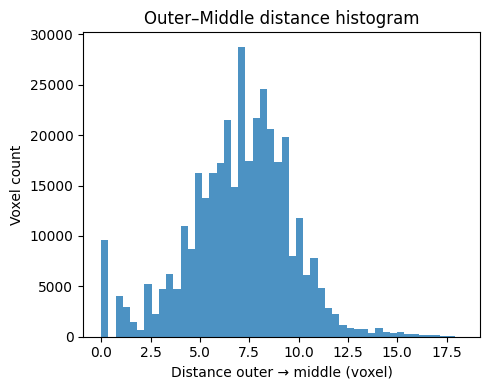

In [76]:
import matplotlib.pyplot as plt
import numpy as np

def plot_distance_histogram(d_outer, unit="voxel"):
    plt.figure(figsize=(5,4))
    plt.hist(d_outer, bins=50, alpha=0.8)
    plt.xlabel(f"Distance outer → middle ({unit})")
    plt.ylabel("Voxel count")
    plt.title("Outer–Middle distance histogram")
    plt.tight_layout()
    plt.show()

plot_distance_histogram(d_outer, unit="voxel")   # voxel_size가 nm 기준이면


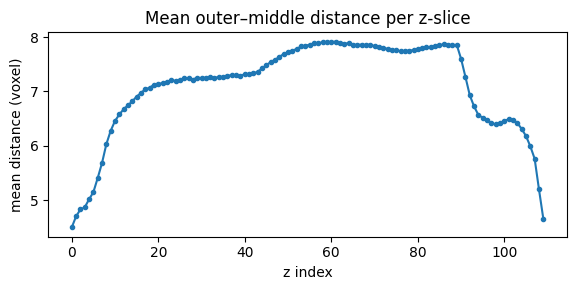

In [77]:
def plot_distance_by_z(outer_mask, d_outer, unit="voxel"):
    # outer_mask에서 outer voxel들의 z-index 추출
    z_idx, y_idx, x_idx = np.nonzero(outer_mask)
    assert d_outer.shape[0] == z_idx.shape[0]

    # 같은 z에서 평균 거리 계산
    max_z = outer_mask.shape[0]
    mean_per_z = np.full(max_z, np.nan)

    for z in range(max_z):
        mask_z = (z_idx == z)
        if np.any(mask_z):
            mean_per_z[z] = d_outer[mask_z].mean()

    plt.figure(figsize=(6,3))
    plt.plot(np.arange(max_z), mean_per_z, marker=".")
    plt.xlabel("z index")
    plt.ylabel(f"mean distance ({unit})")
    plt.title("Mean outer–middle distance per z-slice")
    plt.tight_layout()
    plt.show()

plot_distance_by_z(outer_mask_cropped, d_outer, unit="voxel")


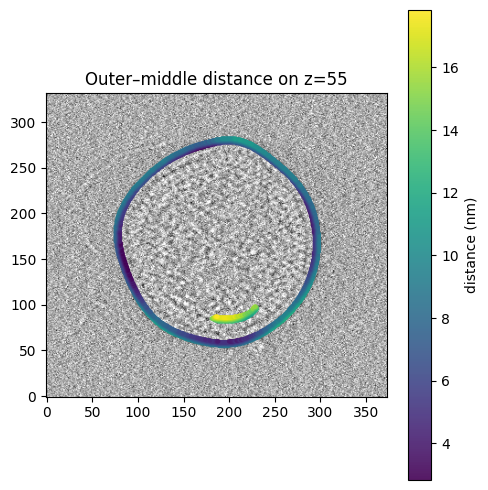

In [78]:
def visualize_slice_with_thickness_overlay(norm_data, outer_mask, d_outer,
                                           z_slice=None, unit="voxel"):

    z_idx, y_idx, x_idx = np.nonzero(outer_mask)
    if z_slice is None:
        z_slice = outer_mask.shape[0] // 2

    # 해당 z-slice의 outer voxel만 추출
    sel = (z_idx == z_slice)
    if not np.any(sel):
        print(f"No outer voxels at z={z_slice}")
        return

    y_sel = y_idx[sel]
    x_sel = x_idx[sel]
    d_sel = d_outer[sel]

    plt.figure(figsize=(5,5))
    plt.imshow(norm_data[z_slice], cmap="gray")
    sc = plt.scatter(x_sel, y_sel, c=d_sel, s=5, alpha=0.9)
    plt.gca().invert_yaxis()
    plt.colorbar(sc, label=f"distance ({unit})")
    plt.title(f"Outer–middle distance on z={z_slice}")
    plt.tight_layout()
    plt.show()

visualize_slice_with_thickness_overlay(norm_data_cropped, outer_mask_cropped, d_outer,
                                       z_slice=outer_mask_cropped.shape[0]//2,
                                       unit="nm")


In [72]:
import napari
import numpy as np

def napari_outer_distance_points(outer_mask, d_outer):
    z_idx, y_idx, x_idx = np.nonzero(outer_mask)
    coords = np.stack([z_idx, y_idx, x_idx], axis=1)

    viewer = napari.Viewer()
    # tomogram이 있으면 추가
    # viewer.add_image(norm_data, name="cryoET")
    viewer.add_points(
        coords,
        size=1,
        properties={"distance": d_outer},
        face_color="distance",
        face_colormap="turbo",
        name="outer→middle distance"
    )
    return viewer

viewer = napari_outer_distance_points(outer_mask_cropped, d_outer)


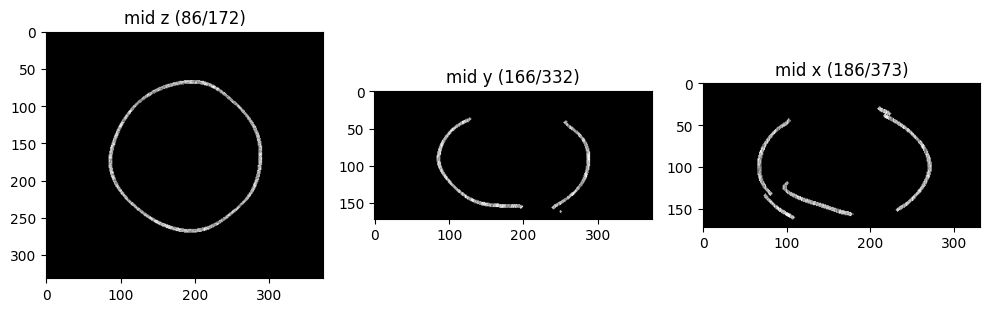

In [80]:
visualize_zyx_midslice(middle_layer)

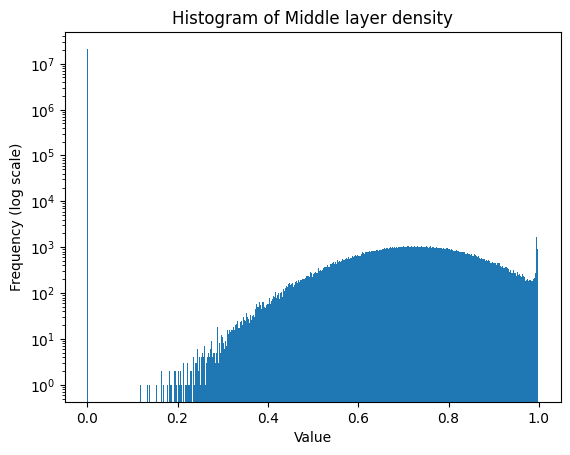

In [79]:
# plot middle layer density
plt.hist(middle_layer.ravel(), bins=1000)    # ravel() flattens the array
plt.yscale('log')
plt.title('Histogram of Middle layer density')
plt.xlabel('Value')
plt.ylabel('Frequency (log scale)')
plt.show()

# 3. Grab Env proteins